In [1]:
import json

FEATURES_PATH = r"C:\Users\MALAY\sentinel\ai\models\phishing\features.json"

with open(FEATURES_PATH, "r") as f:
    model_features = json.load(f)

print("Model expects", len(model_features), "features")

for i, feature in enumerate(model_features, 1):
    print(i, "->", feature)

Model expects 50 features
1 -> URLLength
2 -> DomainLength
3 -> IsDomainIP
4 -> URLSimilarityIndex
5 -> CharContinuationRate
6 -> TLDLegitimateProb
7 -> URLCharProb
8 -> TLDLength
9 -> NoOfSubDomain
10 -> HasObfuscation
11 -> NoOfObfuscatedChar
12 -> ObfuscationRatio
13 -> NoOfLettersInURL
14 -> LetterRatioInURL
15 -> NoOfDegitsInURL
16 -> DegitRatioInURL
17 -> NoOfEqualsInURL
18 -> NoOfQMarkInURL
19 -> NoOfAmpersandInURL
20 -> NoOfOtherSpecialCharsInURL
21 -> SpacialCharRatioInURL
22 -> IsHTTPS
23 -> LineOfCode
24 -> LargestLineLength
25 -> HasTitle
26 -> DomainTitleMatchScore
27 -> URLTitleMatchScore
28 -> HasFavicon
29 -> Robots
30 -> IsResponsive
31 -> NoOfURLRedirect
32 -> NoOfSelfRedirect
33 -> HasDescription
34 -> NoOfPopup
35 -> NoOfiFrame
36 -> HasExternalFormSubmit
37 -> HasSocialNet
38 -> HasSubmitButton
39 -> HasHiddenFields
40 -> HasPasswordField
41 -> Bank
42 -> Pay
43 -> Crypto
44 -> HasCopyrightInfo
45 -> NoOfImage
46 -> NoOfCSS
47 -> NoOfJS
48 -> NoOfSelfRef
49 -> NoOf

In [2]:
import re
import ipaddress
from urllib.parse import urlparse


def is_ip_address(hostname: str) -> int:
    """
    Returns:
        1 -> hostname is an IP address
        0 -> hostname is not an IP address
    """

    if not hostname:
        return 0

    try:
        ipaddress.ip_address(hostname)
        return 1
    except ValueError:
        return 0


def count_subdomains(hostname: str) -> int:
    """
    Example:

    example.com
        -> 0

    login.example.com
        -> 1

    login.secure.example.com
        -> 2
    """

    if not hostname:
        return 0

    parts = hostname.split(".")

    if len(parts) <= 2:
        return 0

    return len(parts) - 2


def extract_url_features(url: str) -> dict:
    """
    Extract URL-only features.

    These are features that can be calculated
    without visiting the website.
    """

    original_url = url.strip()

    # Add scheme if user enters:
    # example.com/login
    if not re.match(r"^[a-zA-Z][a-zA-Z0-9+.-]*://", original_url):
        url_for_parse = "http://" + original_url
    else:
        url_for_parse = original_url

    parsed = urlparse(url_for_parse)

    hostname = parsed.hostname or ""

    path = parsed.path or ""

    query = parsed.query or ""

    fragment = parsed.fragment or ""

    # URL components
    url_length = len(original_url)

    domain_length = len(hostname)

    # Character counts
    letters_in_url = sum(
        character.isalpha()
        for character in original_url
    )

    digits_in_url = sum(
        character.isdigit()
        for character in original_url
    )

    equals_count = original_url.count("=")

    question_count = original_url.count("?")

    ampersand_count = original_url.count("&")

    # Common special characters
    special_characters = set(
        "@!#$%^*()_+-=[]{}|;:',<>"
    )

    other_special_characters = sum(
        character in special_characters
        for character in original_url
    )

    # Domain
    domain_letters = sum(
        character.isalpha()
        for character in hostname
    )

    domain_digits = sum(
        character.isdigit()
        for character in hostname
    )

    # Path
    path_length = len(path)

    # HTTPS
    is_https = int(
        parsed.scheme.lower() == "https"
    )

    # IP
    domain_is_ip = is_ip_address(hostname)

    # Subdomains
    number_of_subdomains = count_subdomains(
        hostname
    )

    # Port
    has_port = int(
        parsed.port is not None
    )

    # Shortening services
    shortening_domains = {
        "bit.ly",
        "tinyurl.com",
        "t.co",
        "goo.gl",
        "ow.ly",
        "is.gd",
        "buff.ly",
        "cutt.ly",
        "shorturl.at"
    }

    is_shortened_url = int(
        hostname.lower() in shortening_domains
    )

    # Suspicious patterns
    suspicious_words = [
        "login",
        "verify",
        "verification",
        "secure",
        "account",
        "update",
        "confirm",
        "password",
        "signin",
        "bank",
        "paypal",
        "wallet",
        "recover",
        "authentication"
    ]

    url_lower = original_url.lower()

    suspicious_word_count = sum(
        word in url_lower
        for word in suspicious_words
    )

    # @ in URL can be suspicious
    has_at_symbol = int(
        "@" in original_url
    )

    # Excessive hyphens
    hyphen_count = original_url.count("-")

    # Number of dots
    dot_count = original_url.count(".")

    features = {

        "URLLength":
            url_length,

        "DomainLength":
            domain_length,

        "IsDomainIP":
            domain_is_ip,

        "NoOfSubDomain":
            number_of_subdomains,

        "NoOfLettersInURL":
            letters_in_url,

        "NoOfDigitsInURL":
            digits_in_url,

        "NoOfEqualsInURL":
            equals_count,

        "NoOfQMarkInURL":
            question_count,

        "NoOfAmpersandInURL":
            ampersand_count,

        "NoOfOtherSpecialCharsInURL":
            other_special_characters,

        "NoOfLettersInDomain":
            domain_letters,

        "NoOfDigitsInDomain":
            domain_digits,

        "PathLength":
            path_length,

        "IsHTTPS":
            is_https,

        "HasPort":
            has_port,

        "IsShortenedURL":
            is_shortened_url,

        "SuspiciousWordCount":
            suspicious_word_count,

        "HasAtSymbol":
            has_at_symbol,

        "HyphenCount":
            hyphen_count,

        "DotCount":
            dot_count,

        "QueryLength":
            len(query),

        "FragmentLength":
            len(fragment),
    }

    return features

In [3]:
import sys

sys.path.insert(
    0,
    r"C:\Users\MALAY\sentinel\ai\app"
)

In [5]:
from services.url_feature_extractor import extract_url_features

In [8]:
url = "https://example1234.com/login"

features = extract_url_features(url)

features

{'URLLength': 29,
 'DomainLength': 15,
 'IsDomainIP': 0,
 'NoOfSubDomain': 0,
 'NoOfLettersInURL': 20,
 'NoOfDigitsInURL': 4,
 'NoOfEqualsInURL': 0,
 'NoOfQMarkInURL': 0,
 'NoOfAmpersandInURL': 0,
 'NoOfOtherSpecialCharsInURL': 1,
 'NoOfLettersInDomain': 10,
 'NoOfDigitsInDomain': 4,
 'PathLength': 6,
 'IsHTTPS': 1,
 'HasPort': 0,
 'IsShortenedURL': 0,
 'SuspiciousWordCount': 1,
 'HasAtSymbol': 0,
 'HyphenCount': 0,
 'DotCount': 1,
 'QueryLength': 0,
 'FragmentLength': 0}

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

feature_df = pd.DataFrame(
    list(features.items()),
    columns=["Feature", "Value"]
)

feature_df

,Feature,Value
0,URLLength,29
1,DomainLength,15
2,IsDomainIP,0
3,NoOfSubDomain,0
4,NoOfLettersInURL,20
5,NoOfDigitsInURL,4
6,NoOfEqualsInURL,0
7,NoOfQMarkInURL,0
8,NoOfAmpersandInURL,0
9,NoOfOtherSpecialCharsInURL,1


<Figure size 1200x800 with 0 Axes>

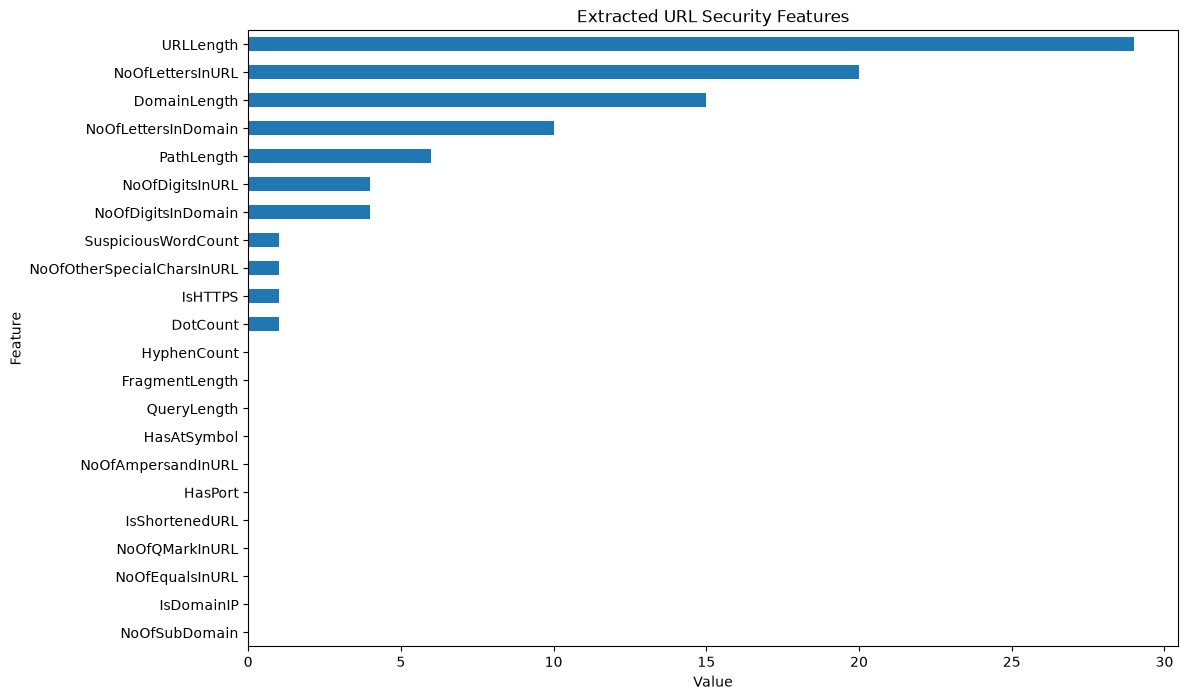

In [10]:
plt.figure(figsize=(12, 8))

feature_df.sort_values(
    "Value",
    ascending=True
).plot(
    x="Feature",
    y="Value",
    kind="barh",
    figsize=(12, 8),
    legend=False
)

plt.title("Extracted URL Security Features")

plt.xlabel("Value")

plt.ylabel("Feature")

plt.show()

In [11]:
for feature in model_features:
    print(feature)

URLLength
DomainLength
IsDomainIP
URLSimilarityIndex
CharContinuationRate
TLDLegitimateProb
URLCharProb
TLDLength
NoOfSubDomain
HasObfuscation
NoOfObfuscatedChar
ObfuscationRatio
NoOfLettersInURL
LetterRatioInURL
NoOfDegitsInURL
DegitRatioInURL
NoOfEqualsInURL
NoOfQMarkInURL
NoOfAmpersandInURL
NoOfOtherSpecialCharsInURL
SpacialCharRatioInURL
IsHTTPS
LineOfCode
LargestLineLength
HasTitle
DomainTitleMatchScore
URLTitleMatchScore
HasFavicon
Robots
IsResponsive
NoOfURLRedirect
NoOfSelfRedirect
HasDescription
NoOfPopup
NoOfiFrame
HasExternalFormSubmit
HasSocialNet
HasSubmitButton
HasHiddenFields
HasPasswordField
Bank
Pay
Crypto
HasCopyrightInfo
NoOfImage
NoOfCSS
NoOfJS
NoOfSelfRef
NoOfEmptyRef
NoOfExternalRef


In [12]:
features.keys()

dict_keys(['URLLength', 'DomainLength', 'IsDomainIP', 'NoOfSubDomain', 'NoOfLettersInURL', 'NoOfDigitsInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL', 'NoOfLettersInDomain', 'NoOfDigitsInDomain', 'PathLength', 'IsHTTPS', 'HasPort', 'IsShortenedURL', 'SuspiciousWordCount', 'HasAtSymbol', 'HyphenCount', 'DotCount', 'QueryLength', 'FragmentLength'])

In [13]:
print("MODEL FEATURES")
print("================")

for feature in model_features:
    print(feature)

print("\nEXTRACTABLE FEATURES")
print("====================")

for feature in features:
    print(feature)


MODEL FEATURES
URLLength
DomainLength
IsDomainIP
URLSimilarityIndex
CharContinuationRate
TLDLegitimateProb
URLCharProb
TLDLength
NoOfSubDomain
HasObfuscation
NoOfObfuscatedChar
ObfuscationRatio
NoOfLettersInURL
LetterRatioInURL
NoOfDegitsInURL
DegitRatioInURL
NoOfEqualsInURL
NoOfQMarkInURL
NoOfAmpersandInURL
NoOfOtherSpecialCharsInURL
SpacialCharRatioInURL
IsHTTPS
LineOfCode
LargestLineLength
HasTitle
DomainTitleMatchScore
URLTitleMatchScore
HasFavicon
Robots
IsResponsive
NoOfURLRedirect
NoOfSelfRedirect
HasDescription
NoOfPopup
NoOfiFrame
HasExternalFormSubmit
HasSocialNet
HasSubmitButton
HasHiddenFields
HasPasswordField
Bank
Pay
Crypto
HasCopyrightInfo
NoOfImage
NoOfCSS
NoOfJS
NoOfSelfRef
NoOfEmptyRef
NoOfExternalRef

EXTRACTABLE FEATURES
URLLength
DomainLength
IsDomainIP
NoOfSubDomain
NoOfLettersInURL
NoOfDigitsInURL
NoOfEqualsInURL
NoOfQMarkInURL
NoOfAmpersandInURL
NoOfOtherSpecialCharsInURL
NoOfLettersInDomain
NoOfDigitsInDomain
PathLength
IsHTTPS
HasPort
IsShortenedURL
Suspicious

In [14]:
print(df.columns.tolist())

NameError: name 'df' is not defined